In [1]:
import json
import os
import numpy as np

In [2]:
runs_eval_path = '/vision/asomaya1/active-rir/runs'
stats_file_name = 'test_telephone_stats_0.json'

#specify model to run
run = 'DDPPO_SD_NA_1500_continuous_all_train_v4'

full_path = os.path.join(runs_eval_path, run, "tb", stats_file_name)


# Open and load the JSON file
with open(full_path, 'r') as json_file:
    data = json.load(json_file)

In [3]:
# Dictionary to store aggregated metrics for each scene
scene_metrics = {}
# Iterate through the dictionary and group metrics by scene
for key, metrics in data.items():
    # Split the key to extract the scene name
    parts = key.split('/')
    scene_name = parts[3]  # Assuming the scene name is always in the fourth position
    if scene_name not in scene_metrics:
        scene_metrics[scene_name] = {key: [] for key in metrics.keys()}
    # Append metrics to the scene-specific list
    for key in scene_metrics[scene_name]:
        scene_metrics[scene_name][key].append(metrics[key])
# Compute the average metrics for each scene
average_scene_metrics = {}
median_scene_metrics = {}
std_scene_metrics = {}
num_eps_per_scene = {}
for scene_name, metrics in scene_metrics.items():
    for key in metrics:
        average_scene_metrics[scene_name] = {'average_{}'.format(key): sum(metrics[key]) / len(metrics[key]) for key in metrics.keys()}
        median_scene_metrics[scene_name] = {'median_{}'.format(key): np.median(metrics[key]) for key in metrics.keys()}
        std_scene_metrics[scene_name] = {'std_{}'.format(key): np.std(metrics[key]) for key in metrics.keys()}
        num_eps_per_scene[scene_name] = {key: len(metrics[key]) for key in metrics.keys()}
# Print the average metrics for each scene

for scene_name, metrics in average_scene_metrics.items():
    print(f'Scene: {scene_name}')
    print("num episodes:", num_eps_per_scene[scene_name])
    for key in metrics.keys():
        print(f'{key}: {metrics[key]}')

Scene: fzynW3qQPVF
num episodes: {'reward': 326, 'stft_l1_distance': 326, 'diff_rt_startFrom60dB': 326, 'rel_diff_rt_startFrom60dB': 326, 'rel_diff_edt': 326, 'diff_drr_3ms': 326, 'rel_diff_drr_3ms': 326}
average_reward: 0.0
average_stft_l1_distance: 0.01451362217826472
average_diff_rt_startFrom60dB: 0.236117622060327
average_rel_diff_rt_startFrom60dB: 0.3337329010442055
average_rel_diff_edt: 0.4817096156552308
average_diff_drr_3ms: 3.3159558025112634
average_rel_diff_drr_3ms: 0.41480750587006665
Scene: gxdoqLR6rwA
num episodes: {'reward': 213, 'stft_l1_distance': 213, 'diff_rt_startFrom60dB': 213, 'rel_diff_rt_startFrom60dB': 213, 'rel_diff_edt': 213, 'diff_drr_3ms': 213, 'rel_diff_drr_3ms': 213}
average_reward: 0.0
average_stft_l1_distance: 0.007851737265253558
average_diff_rt_startFrom60dB: 0.015488116197183084
average_rel_diff_rt_startFrom60dB: 0.015926636590170677
average_rel_diff_edt: 0.43805812278013156
average_diff_drr_3ms: 1.9412777345234133
average_rel_diff_drr_3ms: 0.2177281

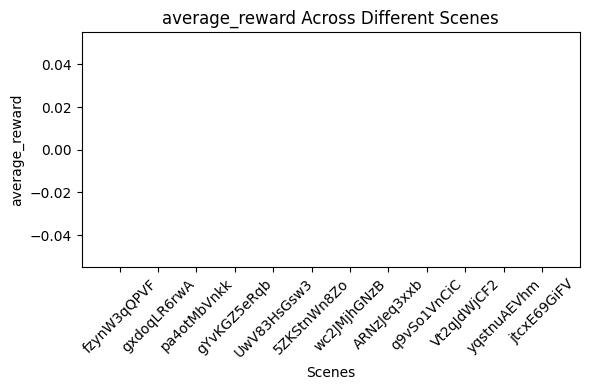

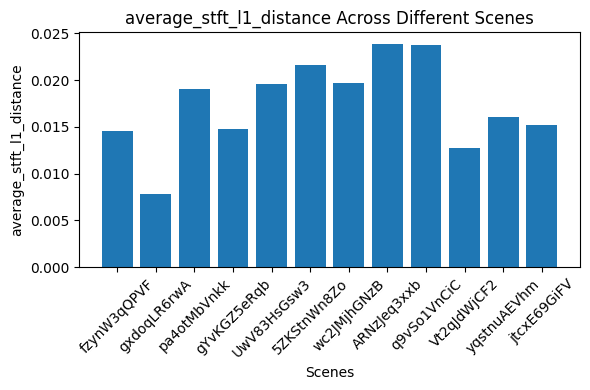

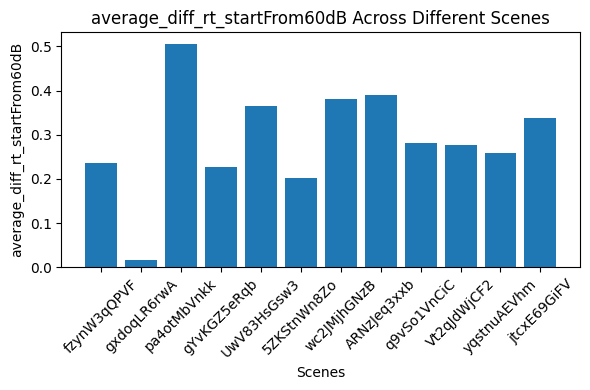

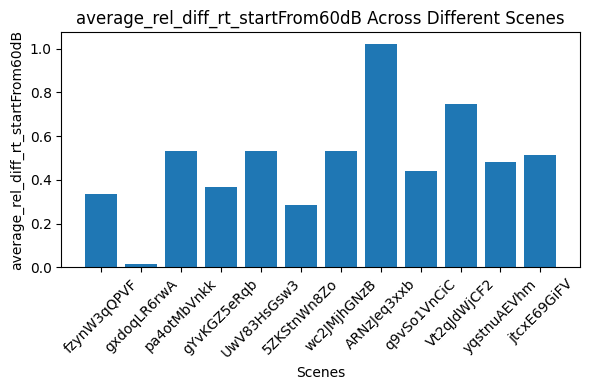

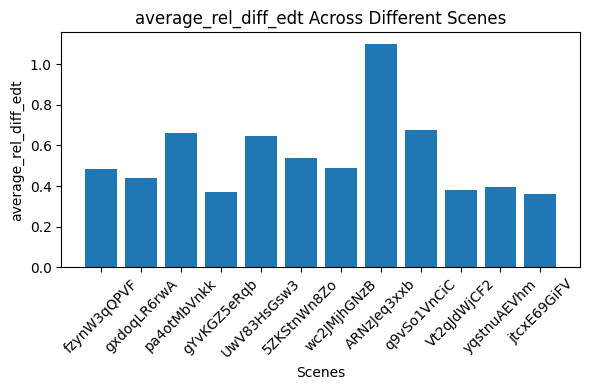

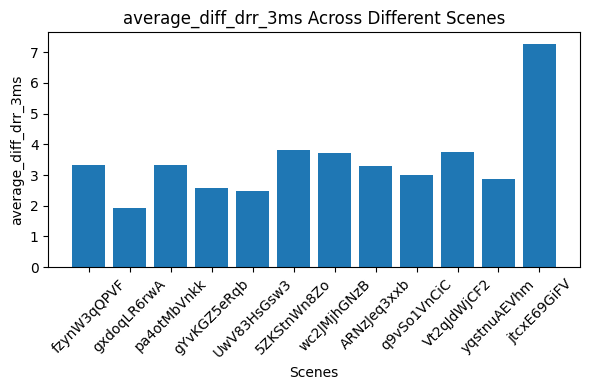

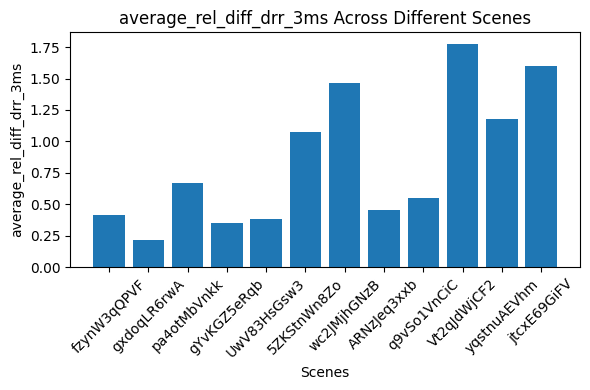

In [4]:
import matplotlib.pyplot as plt

# Metrics to plot
metrics_to_plot = list(metrics.keys())

# Create a bar plot for each metric
for metric in metrics_to_plot:
    # Extract metric values for all scenes
    metric_values = [average_scene_metrics[scene][metric] for scene in average_scene_metrics]
    scenes = list(average_scene_metrics.keys())

    # Create the bar plot
    plt.figure(figsize=(6, 4))
    plt.bar(scenes, metric_values)
    plt.xlabel('Scenes')
    plt.ylabel(metric)
    plt.title(f'{metric} Across Different Scenes')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Show or save the plot (you can choose either option)
    # To show the plot:
    plt.show()

    # To save the plot as an image file (e.g., PNG):
    # plt.savefig(f'{metric}_bar_plot.png')


In [5]:
with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_sizes = json.load(f)

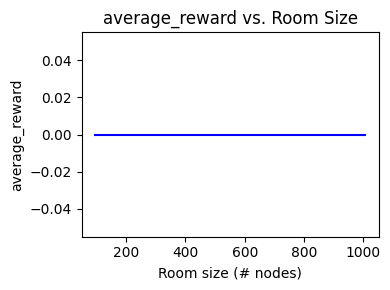

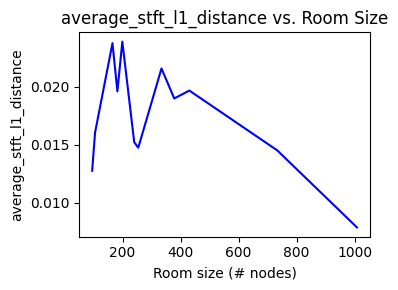

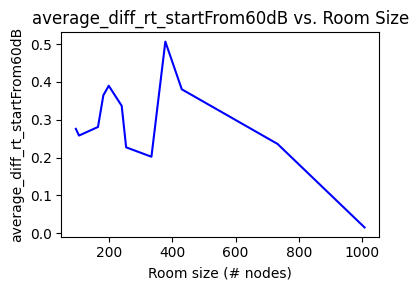

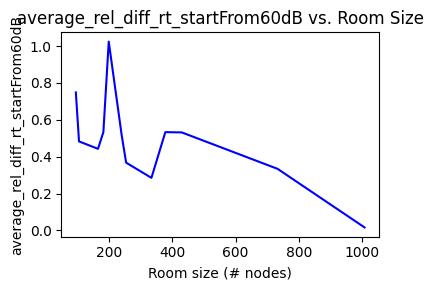

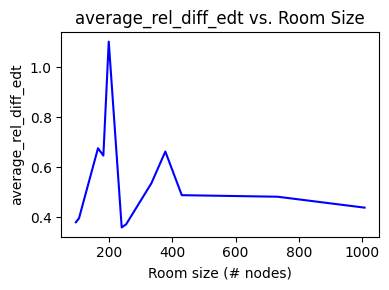

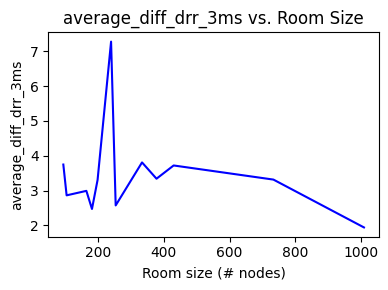

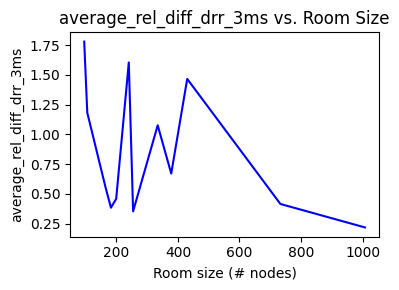

In [6]:
# Create scatter plots for each metric as a function of the integer
for metric in metrics_to_plot:
    # Extract metric values for all scenes
    metric_values = [average_scene_metrics[scene][metric] for scene in average_scene_metrics]
    integers = [scene_sizes[scene] for scene in average_scene_metrics]

    sorted_data = sorted(zip(integers, metric_values), key=lambda x: x[0])
    sorted_integers, sorted_metric_values = zip(*sorted_data)

    plt.figure(figsize=(4, 3))  # Adjust the figsize if needed
    plt.plot(sorted_integers, sorted_metric_values, linestyle='-', color='b')  # Line connecting points
    plt.xlabel('Room size (# nodes)')
    plt.ylabel(metric)
    plt.title(f'{metric} vs. Room Size')
    plt.tight_layout()
    plt.show()


In [7]:
# Calculate mean, median, and std for each key
results = {}
round_val = 5

first_episode_name = list(data.keys())[0]

for key in data[first_episode_name].keys():
    values = [inner_dict[key] for inner_dict in data.values()]
    mean = np.mean(values)
    median = np.median(values)
    std = np.std(values)
    
    results[key] = {'mean': np.round(mean,round_val), 'median': np.round(median,round_val), 'std': np.round(std,round_val)}

# Print the results
for key, stats in results.items():
    print(f"Key: {key}")
    print(f"Mean: {stats['mean']}")
    #print(f"Median: {stats['median']}")


Key: reward
Mean: 0.0
Key: stft_l1_distance
Mean: 0.01349
Key: diff_rt_startFrom60dB
Mean: 0.19129
Key: rel_diff_rt_startFrom60dB
Mean: 0.2735
Key: rel_diff_edt
Mean: 0.48584
Key: diff_drr_3ms
Mean: 2.89807
Key: rel_diff_drr_3ms
Mean: 0.44515


In [8]:
""" # Create an empty dictionary to store the median values
median_values = {}

# Extract the lists of values for each key and calculate the median
for key in average_scene_metrics['fzynW3qQPVF'].keys():
    values = [data[key] for data in average_scene_metrics.values()]
    median = np.median(values)
    median_values[key] = median

# Print or use the median values as needed
median_values """

{'average_reward': 0.0,
 'average_stft_l1_distance': 0.01752387878459915,
 'average_diff_rt_startFrom60dB': 0.2786237106821895,
 'average_rel_diff_rt_startFrom60dB': 0.49906901214819865,
 'average_rel_diff_edt': 0.48482844590619356,
 'average_diff_drr_3ms': 3.310541700946012,
 'average_rel_diff_drr_3ms': 0.6091684963110832}